# ITI5202 Assignment 2A : Building Models for Building Energy Prediction

Group: H

Member: 

- Kezia Florayn Magda
- Muhammad Arief Kurniawan - 35676884

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3) 
    * [Part 4 : Data Ethics, Privacy, and Security](#part-4)  
    * AI Declaration

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

The specification asks for all CPU cores, with a footnote permitting fewer if RAM is insufficient. This notebook runs in a container limited to approximately 10 GB, and using all cores with a larger driver heap caused the JVM to be terminated during model training. We therefore use four cores and a 3 GB driver heap.

In [1]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[4] rather than local[*]: the container is capped at ~10GB and each worker
# thread carries JVM overhead. The spec permits reducing cores when RAM is limited.
master = "local[4]"
app_name = "assignment_2a"

spark_conf = (SparkConf()
    .setMaster(master)
    .setAppName(app_name)
    .set("spark.driver.memory", "3g")
    .set("spark.sql.files.maxPartitionBytes", "32m")
    .set("spark.sql.shuffle.partitions", "32"))

In [2]:
# Create the SparkSession from the configuration above

from pyspark.sql import SparkSession


spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()

# getOrCreate() reuses an existing session if one is already running, and driver
# memory cannot be changed after the JVM starts, so print the settings back to
# confirm the configuration was actually applied rather than silently inherited
print("App name        :", spark.sparkContext.appName)
print("Master          :", spark.sparkContext.master)
print("Max partition   :", spark.conf.get("spark.sql.files.maxPartitionBytes"))

spark

App name        : assignment_2a
Master          : local[4]
Max partition   : 32m


1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [3]:
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    LongType,
    StringType,
    DoubleType,
    TimestampType,
    DecimalType
)

In [4]:
# Schemas follow the metadata data types, with three documented deviations noted below.
# All fields are nullable: the metadata flags missing values in several weather columns,
# and an explicit schema makes unparseable or empty values load as null for the Imputer.

building_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    # metadata says Decimal; loaded as Double since these feed Spark ML,
    # which expects double-typed features
    StructField("latent_y", DoubleType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", DoubleType(), True)
])


meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    # Decimal(18,4) gives exact arithmetic for the summed label; precision 18
    # accommodates the largest observed readings without overflow
    StructField("value", DecimalType(18, 4), True),
    StructField("row_id", IntegerType(), True)
])


weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    # precision/scale sized to the physical ranges: temperatures to two decimals,
    # pressure around 1000 mb to one, wind speed to one
    StructField("air_temperature", DecimalType(5, 2), True),
    # metadata says Integer (0-8 oktas); loaded as Double because the Imputer
    # produces a fractional mean, which an Integer column would truncate
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DecimalType(5, 2), True),
    StructField("sea_level_pressure", DecimalType(6, 1), True),
    # metadata says Integer (0-360 degrees); Double for the same imputation reason
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DecimalType(4, 1), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [5]:
# Timestamp format matching the source files; required so ts and timestamp parse
# to TimestampType rather than null under the explicit schema
timestamp_format = "yyyy-MM-dd HH:mm:ss.SSS"
dataset_path = "dataset"

In [6]:
# Loading with an explicit schema rather than inferSchema avoids a full scan of the
# data and guarantees the declared types, rather than letting Spark guess from a sample


building_df = (
    spark.read
    .option("header", "true")
    .schema(building_schema)
    .csv(f"{dataset_path}/building_information.csv")
)

# building_information.csv needs no timestampFormat: it holds static metadata only
meters_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(meters_schema)
    .csv(f"{dataset_path}/meters.csv")
)

weather_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(weather_schema)
    .csv(f"{dataset_path}/weather.csv")
)

Verifying the loaded schemas

Printing the schemas confirms the declared types were applied rather than inferred. Two things to check in the output: ts and timestamp resolved to timestamp rather than string, which confirms the format string parsed correctly, and the decimal columns carry their declared precision and scale.

In [7]:
building_df.printSchema()
meters_df.printSchema()
weather_df.printSchema()

root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)

root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: decimal(18,4) (nullable = true)
 |-- row_id: integer (nullable = true)

root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: decimal(5,2) (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: decimal(5,2) (nullable = true)
 |-- sea_level_pressure: decimal(6,1) (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: decim

All three schemas match the metadata, with the three deviations noted above: cloud_coverage and wind_direction are loaded as double rather than integer so that imputed means are not truncated, and the latent_* columns as double for Spark ML compatibility.

------------------------------

- Inspecting the loaded data

A first look at each table confirms the values parsed sensibly and surfaces issues to address later. Two are already visible in the weather sample: cloud_coverage and sea_level_pressure contain nulls, which 1.2.2 handles with the MLlib Imputer.

In [8]:
# truncate=False so full timestamps and long primary_use values are visible

building_df.show(5, truncate=False)
meters_df.show(5, truncate=False)
weather_df.show(5, truncate=False)

+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|site_id|building_id|primary_use  |square_feet|floor_count|row_id|year_built|latent_y|latent_s |latent_r|
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|2      |165        |Warehouse    |3877       |1          |166   |1982      |18.0    |3.5884957|3.0     |
|2      |229        |Education    |140092     |1          |230   |1999      |1.0     |5.1464133|3.0     |
|1      |121        |Education    |150318     |9          |122   |1913      |87.0    |4.2227683|2.0     |
|8      |871        |Entertainment|1536       |1          |872   |1974      |26.0    |3.186391 |4.0     |
|9      |939        |Residential  |8051       |1          |940   |1980      |20.0    |3.90585  |4.0     |
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
only showing top 5 rows
+-----------+---------

In [95]:
print("building:", building_df.count())
print("meters  :", meters_df.count())
print("weather :", weather_df.count())

building: 1000
meters  : 13825018
weather : 139773


In [96]:
meters_df.select("building_id").distinct() \
    .join(building_df.select("building_id"), "building_id", "left_anti").count()

0

The three tables sit at very different scales. meters holds 13.8 million hourly readings, which is why 1.2.1 aggregates to 6-hour blocks: the specification notes a grid operator does not need hourly granularity, and the aggregation reduces the data by roughly a factor of ten. weather has 139,773 rows, consistent with 16 sites recorded hourly across one year. building has 1,000 rows of static metadata, small enough that its join broadcasts efficiently.

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


In [9]:
import pyspark.sql.functions as F

In [10]:
# hour / 6 maps each reading to one of four blocks: 0-5 -> 0, 6-11 -> 1,
# 12-17 -> 2, 18-23 -> 3. Integer casting truncates, so floor() is not needed.
# hour() reads session-local time, so blocks align to the local clock windows
# the specification defines regardless of the session timezone.

meters_6h_df = (
    meters_df
    .withColumn("date", F.to_date("ts"))
    .withColumn("six_hour_block", (F.hour("ts") / 6).cast("int"))
    # grouped by building only, not meter_type: the metadata states the label is
    # the aggregated value of the four meters, and the task says "for each building"
    .groupBy("building_id", "date", "six_hour_block")
    
    # sum not average: energy consumption accumulates over the interval
    .agg(F.sum("value").cast("double").alias("label"))
    # readable interval label matching the windows named in the task
    .withColumn(
        "interval",
        F.when(F.col("six_hour_block") == 0, "00:00-05:59")
         .when(F.col("six_hour_block") == 1, "06:00-11:59")
         .when(F.col("six_hour_block") == 2, "12:00-17:59")
         .otherwise("18:00-23:59")
    )
)

In [11]:
meters_df.count() - meters_df.select("row_id").distinct().count()

0

In [97]:
# 1.2.1 deliverable: show the aggregated label table
meters_6h_df.orderBy("building_id", "date", "six_hour_block").show(10, truncate=False)
print("6-hour blocks:", meters_6h_df.count())

+-----------+----------+--------------+-----+-----------+
|building_id|date      |six_hour_block|label|interval   |
+-----------+----------+--------------+-----+-----------+
|0          |2022-01-01|0             |0.0  |00:00-05:59|
|0          |2022-01-01|1             |0.0  |06:00-11:59|
|0          |2022-01-01|2             |0.0  |12:00-17:59|
|0          |2022-01-01|3             |0.0  |18:00-23:59|
|0          |2022-01-02|0             |0.0  |00:00-05:59|
|0          |2022-01-02|1             |0.0  |06:00-11:59|
|0          |2022-01-02|2             |0.0  |12:00-17:59|
|0          |2022-01-02|3             |0.0  |18:00-23:59|
|0          |2022-01-03|0             |0.0  |00:00-05:59|
|0          |2022-01-03|1             |0.0  |06:00-11:59|
+-----------+----------+--------------+-----+-----------+
only showing top 10 rows
6-hour blocks: 1423715


In [98]:
meters_6h_df.filter(F.col("building_id") == 0) \
    .agg(F.min("label"), F.max("label"), F.avg("label"), F.count("*")).show()

+----------+----------+-----------------+--------+
|min(label)|max(label)|       avg(label)|count(1)|
+----------+----------+-----------------+--------+
|       0.0|  1928.916|881.1373485616436|    1460|
+----------+----------+-----------------+--------+



Aggregating 13,825,018 hourly readings produces 1,423,715 six-hour blocks, a reduction of roughly ten times, which is the efficiency gain the task describes. The count is consistent with 1,000 buildings recorded over 365 days in four daily blocks.

The first rows show building 0 at zero consumption for several consecutive days in early January, but across the full year it averages 881 with a maximum of 1,929, so this reflects a period of low or absent readings rather than an inactive meter. Zero labels account for 3.7% of the training data overall. The specification notes the meters table contains values missing due to sensor or network failures, so these are more likely absent readings than genuine zero consumption; this is examined in Part 3.

In [99]:
# do zero labels cluster in particular buildings or particular dates?
meters_6h_df.filter(F.col("label") == 0) \
    .groupBy("date").count().orderBy(F.desc("count")).show(5)

+----------+-----+
|      date|count|
+----------+-----+
|2022-01-25|  503|
|2022-01-20|  448|
|2022-02-23|  423|
|2022-02-24|  382|
|2022-01-23|  362|
+----------+-----+
only showing top 5 rows


In [100]:
meters_6h_df.filter(F.col("label") == 0) \
    .withColumn("month", F.month("date")) \
    .groupBy("month").count().orderBy("month").show(12)

+-----+-----+
|month|count|
+-----+-----+
|    1|10939|
|    2| 9311|
|    3| 8690|
|    4| 8551|
|    5| 5732|
|    6| 1018|
|    7| 1920|
|    8| 1011|
|    9| 1345|
|   10| 2710|
|   11|  982|
|   12|  872|
+-----+-----+



Zero labels and the specification's note on missing meter values

The specification notes the meters table contains values missing due to sensor or network failures. Zero labels account for 3.7% of the training data and are not randomly distributed. They cluster on particular dates, with 503 on 2022-01-25 and 448 on 2022-01-20 against roughly 4,000 blocks per day, and they decline steadily across the year from 10,939 in January to 872 in December. The first five months contain 81% of all zeros.

Both patterns point to system-level data collection issues rather than genuine zero consumption: date clustering indicates outages affecting many buildings simultaneously, and the monotonic annual decline is consistent with monitoring coverage improving as the deployment matured.

Imputing these values was considered and rejected. The label is the sum of meter readings for a block, so imputing it would fabricate the target rather than fill a feature, and a genuine zero cannot be reliably distinguished from a lost reading. Retaining them means the model is trained partly on absent readings, which contributes to the error observed in Part 2. The building-history feature introduced later partially compensates, since it supplies each building's typical consumption for that block independently of whether the reading is complete.

-----------------

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [101]:
from pyspark.ml.feature import Imputer
from pyspark.sql.types import NumericType


In [102]:
# Derive the column list from the schema rather than hardcoding names.
# site_id is excluded because it is numeric but an identifier: a mean site
# has no meaning. timestamp is excluded automatically, as TimestampType is
# not a NumericType.
weather_cols = [
    f.name for f in weather_df.schema.fields
    if isinstance(f.dataType, NumericType) and f.name != "site_id"
]

In [103]:
# outputCols set to the same names so the imputed values overwrite in place
# rather than creating parallel columns. Nulls are always treated as missing
# by the Imputer, so the missingValue parameter is left at its default.

imputer = Imputer(
    inputCols=weather_cols,
    outputCols=weather_cols,
    strategy="mean"
)

# Fit once and reuse: imputer_model holds the computed means, shown below

imputer_model = imputer.fit(weather_df)
weather_imputed_df = imputer.fit(weather_df).transform(weather_df)

In [104]:
# Evidence the imputation worked: null counts before and after
def null_counts(df, cols):
    return df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in cols])

null_counts(weather_df, weather_cols).show()
null_counts(weather_imputed_df, weather_cols).show()

+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|             55|         69173|            113|             10618|          6268|       304|
+---------------+--------------+---------------+------------------+--------------+----------+

+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|              0|             0|              0|                 0|             0|         0|
+---------------+--------------+---------------+------------------+--------------+----------+



In [105]:
# The mean value substituted into each column
imputer_model.surrogateDF.show()

+------------------+------------------+------------------+------------------+------------------+-----------------+
|   air_temperature|    cloud_coverage|   dew_temperature|sea_level_pressure|    wind_direction|       wind_speed|
+------------------+------------------+------------------+------------------+------------------+-----------------+
|14.418106471607175|2.1493059490084985|7.3501582414435855|1016.1580380163365|180.52663196134975|3.560527429036524|
+------------------+------------------+------------------+------------------+------------------+-----------------+



In [106]:
total = weather_df.count()
null_counts(weather_df, weather_cols).show()
print("total rows:", total)

+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|             55|         69173|            113|             10618|          6268|       304|
+---------------+--------------+---------------+------------------+--------------+----------+

total rows: 139773


In [107]:
print("rows before:", weather_df.count(), " after:", weather_imputed_df.count())

rows before: 139773  after: 139773


Null counts fall to zero across all six columns while the row count stays at 139,773, which matters because the task specifies handling gaps without deleting incomplete records.

Two observations affect later feature selection. cloud_coverage was missing in 69,173 of 139,773 rows, or 49.5%, so mean imputation replaces half the column with the single value 2.149. Its variance is understated and its usable signal limited, which is why it is dropped from the feature set in 2.1. The remaining columns are missing under 8%, where mean imputation is reasonable.

wind_direction is a circular variable measured in degrees from true north, so an arithmetic mean is not physically meaningful: averaging bearings either side of north produces a southerly value. The imputed 180.5° is an artefact of this rather than a prevailing wind. The task specifies mean as the strategy so the code follows it, but the column is excluded from the feature set for this reason.

The surrogate values are otherwise physically plausible: 14.4 °C air temperature, 7.35 °C dew point, 1016.2 mb sea level pressure and 3.56 m/s wind speed, with dew point below air temperature as it must be.

---------------

We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [18]:
from pyspark.sql.window import Window

In [19]:
# 1. Average air temperature per site per month

# Aggregating first keeps the ranking cheap: 16 sites x 12 months = 192 rows,
# rather than windowing over all 139,773 weather rows.
site_month_avg = (
    weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .groupBy("site_id", "month")
    .agg(F.avg("air_temperature").alias("avg_air_temperature"))
)

In [20]:
# 2. Rank months within each site, hottest and coldest

# Partitioning by site_id is essential: the task notes sites may span different
# countries, and sites in opposite hemispheres have opposite summers, so a single
# global ranking would mislabel any site whose seasons run counter to the majority.
w_hot  = Window.partitionBy("site_id").orderBy(F.col("avg_air_temperature").desc())
w_cold = Window.partitionBy("site_id").orderBy(F.col("avg_air_temperature").asc())

season_map = (
    site_month_avg
    .withColumn("hot_rank",  F.row_number().over(w_hot))
    .withColumn("cold_rank", F.row_number().over(w_cold))
    # peak if the month is among the 3 hottest OR the 3 coldest for that site
    .withColumn(
        "season",
        F.when((F.col("hot_rank") <= 3) | (F.col("cold_rank") <= 3), "peak")
         .otherwise("off-peak")
    )
    .select("site_id", "month", "season")
)

In [21]:
# 3. Attach back to the weather data
# season_map is only 192 rows, so Spark broadcasts it rather than shuffling.
weather_season_df = (
    weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .join(season_map, on=["site_id", "month"], how="left")
)

In [22]:
# Verification 1: inspect the classification for the first three sites

site_month_avg.join(season_map, ["site_id", "month"]) \
    .orderBy("site_id", "month").show(36)

+-------+-----+-------------------+--------+
|site_id|month|avg_air_temperature|  season|
+-------+-----+-------------------+--------+
|      0|    1|          14.713118|    peak|
|      0|    2|          16.139655|    peak|
|      0|    3|          21.266263|off-peak|
|      0|    4|          22.431250|off-peak|
|      0|    5|          24.734274|off-peak|
|      0|    6|          27.366389|    peak|
|      0|    7|          28.552823|    peak|
|      0|    8|          27.613575|    peak|
|      0|    9|          26.871944|off-peak|
|      0|   10|          24.038172|off-peak|
|      0|   11|          20.055417|off-peak|
|      0|   12|          19.956989|    peak|
|      1|    1|           6.477554|    peak|
|      1|    2|           6.108905|    peak|
|      1|    3|           6.786874|    peak|
|      1|    4|           8.856885|off-peak|
|      1|    5|          14.107258|off-peak|
|      1|    6|          16.270972|off-peak|
|      1|    7|          18.819220|    peak|
|      1| 

In [23]:
# Verification 2: every site should return exactly 6 peak and 6 off-peak months.
# A count other than 6/6 would mean a month was ranked in both the hottest
# and coldest three, which can only happen with fewer than 6 months of data.

season_map.groupBy("site_id", "season").count().orderBy("site_id", "season").show(32)

+-------+--------+-----+
|site_id|  season|count|
+-------+--------+-----+
|      0|off-peak|    6|
|      0|    peak|    6|
|      1|off-peak|    6|
|      1|    peak|    6|
|      2|off-peak|    6|
|      2|    peak|    6|
|      3|off-peak|    6|
|      3|    peak|    6|
|      4|off-peak|    6|
|      4|    peak|    6|
|      5|off-peak|    6|
|      5|    peak|    6|
|      6|off-peak|    6|
|      6|    peak|    6|
|      7|off-peak|    6|
|      7|    peak|    6|
|      8|off-peak|    6|
|      8|    peak|    6|
|      9|off-peak|    6|
|      9|    peak|    6|
|     10|off-peak|    6|
|     10|    peak|    6|
|     11|off-peak|    6|
|     11|    peak|    6|
|     12|off-peak|    6|
|     12|    peak|    6|
|     13|off-peak|    6|
|     13|    peak|    6|
|     14|off-peak|    6|
|     14|    peak|    6|
|     15|off-peak|    6|
|     15|    peak|    6|
+-------+--------+-----+



In [24]:
# Verification 3: which months each site classifies as peak, to check whether
# any site is southern hemisphere and therefore needed the per-site ranking
site_month_avg.join(season_map, ["site_id", "month"]) \
    .filter(F.col("season") == "peak") \
    .groupBy("site_id").agg(F.collect_list("month").alias("peak_months")) \
    .orderBy("site_id").show(16, truncate=False)

+-------+--------------------+
|site_id|peak_months         |
+-------+--------------------+
|0      |[1, 2, 12, 6, 8, 7] |
|1      |[2, 1, 3, 9, 7, 8]  |
|2      |[1, 12, 2, 8, 6, 7] |
|3      |[1, 2, 12, 6, 7, 8] |
|4      |[12, 1, 2, 10, 6, 9]|
|5      |[2, 3, 1, 9, 7, 8]  |
|6      |[1, 2, 12, 6, 8, 7] |
|7      |[2, 1, 12, 6, 7, 8] |
|8      |[1, 2, 12, 6, 8, 7] |
|9      |[1, 12, 2, 6, 8, 7] |
|10     |[12, 1, 2, 6, 8, 7] |
|11     |[2, 1, 12, 6, 7, 8] |
|12     |[2, 11, 3, 9, 8, 7] |
|13     |[1, 12, 2, 6, 8, 7] |
|14     |[1, 2, 12, 6, 8, 7] |
|15     |[1, 2, 12, 6, 7, 8] |
+-------+--------------------+



Every site returns exactly six peak and six off-peak months, confirming no month was counted in both rankings.

The peak months show all 16 sites are northern hemisphere, each pairing winter months (12, 1, 2) with summer months (6, 7, 8). Three sites show a maritime lag: sites 1 and 5 peak at [1, 2, 3] and [7, 8, 9], and site 12 at [2, 3, 11] and [7, 8, 9], consistent with ocean thermal inertia shifting temperature extremes about a month past the solstices. Site 4 is unusual, taking [6, 9, 10] as its hot months rather than the typical [6, 7, 8].

The per-site ranking therefore did not change any labels for this dataset, but it remains the correct treatment given the task's explicit warning that sites may span different countries.

The classification can rest on very small margins. At site 1, March is peak at 6.79 °C while December is off-peak at 6.98 °C, a difference of 0.19 °C. This is the ranking behaving as specified, but the peak/off-peak boundary is somewhat arbitrary at the margins.

Note also that site 2 ranges from 12.9 °C in January to 36.4 °C in July, while site 1 ranges only from 6.1 °C to 19.2 °C. The sites have genuinely different climates, which is why the classification had to be computed within each site rather than against a global temperature threshold.

-------------------------------------------------------------------------

Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

**Building feature_df**

The label is per building per 6-hour block, but weather is per site per hour, so the two tables must be brought to the same resolution before joining. Weather is aggregated using the same date and block derivation applied to the meters.

In [25]:
weather_6h_df = (
    weather_season_df
    .withColumn("date", F.to_date("timestamp"))
    .withColumn("six_hour_block", (F.hour("timestamp") / 6).cast("int"))
    .groupBy("site_id", "date", "six_hour_block")
    # avg, not sum: weather values are point measurements of a state, unlike
    # meter readings which accumulate over the interval
    .agg(
        F.avg("air_temperature").alias("air_temperature"),
        F.avg("cloud_coverage").alias("cloud_coverage"),
        F.avg("dew_temperature").alias("dew_temperature"),
        F.avg("sea_level_pressure").alias("sea_level_pressure"),
        F.avg("wind_direction").alias("wind_direction"),
        F.avg("wind_speed").alias("wind_speed"),
        # season is constant within a site-month so any value in the group is
        # correct; first() is used because groupBy requires an aggregate
        F.first("season").alias("season")
    )
)

In [26]:
feature_df = (
    meters_6h_df
    # building_df joined first to attach site_id, which the weather join needs
    .join(building_df, on="building_id", how="left")
    .join(weather_6h_df, on=["site_id", "date", "six_hour_block"], how="left")
    # row_id and the interval string are dropped: neither carries predictive
    # information. building_id and site_id are kept as join and grouping keys
    # but excluded from the feature vector in 2.2.
    .select(
        "building_id", "site_id", "date", "six_hour_block",
        "primary_use", "square_feet", "floor_count", "year_built",
        "latent_y", "latent_s", "latent_r",
        "air_temperature", "cloud_coverage", "dew_temperature",
        "sea_level_pressure", "wind_direction", "wind_speed",
        "season",
        "label",
    )
)

In [27]:
# left joins should preserve the label row count exactly; a change would mean
# duplicate keys on the right side of a join

print(meters_6h_df.count(), feature_df.count())   # should match
feature_df.printSchema()

1423715 1423715
root
 |-- building_id: integer (nullable = true)
 |-- site_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- six_hour_block: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)
 |-- air_temperature: decimal(9,6) (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: decimal(9,6) (nullable = true)
 |-- sea_level_pressure: decimal(10,5) (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: decimal(8,5) (nullable = true)
 |-- season: string (nullable = true)
 |-- label: double (nullable = true)



The row count is unchanged at 1,423,715, confirming both joins were one-to-one lookups with no duplication.

The sample rows show the join working across all three sources and illustrate the scale range in the label: building 1168 consumes 352,228 in a single block against 1,210 for building 263, a difference of nearly 300 times. This spread is examined in 1.3.

Note that averaging widened the decimal columns, so air_temperature is now decimal(9,6) rather than decimal(5,2). These are cast to double before assembly in 2.1, since VectorAssembler does not accept decimal types.

In [28]:
# vertical=True prints one record per block rather than a wide table; with 19
# columns the standard output wraps and becomes unreadable
feature_df.show(3, truncate=False, vertical=True)

-RECORD 0--------------------------------
 building_id        | 263                
 site_id            | 2                  
 date               | 2022-01-01         
 six_hour_block     | 0                  
 primary_use        | Education          
 square_feet        | 87673              
 floor_count        | 1                  
 year_built         | 1967               
 latent_y           | 33.0               
 latent_s           | 4.942866           
 latent_r           | 3.0                
 air_temperature    | 12.783333          
 cloud_coverage     | 2.02488432483475   
 dew_temperature    | -6.050000          
 sea_level_pressure | 1016.28333         
 wind_direction     | 270.0              
 wind_speed         | 3.08333            
 season             | peak               
 label              | 1210.424           
-RECORD 1--------------------------------
 building_id        | 791                
 site_id            | 7                  
 date               | 2022-01-01  

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  

a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [29]:
import pyspark.sql.functions as F
from pyspark.sql.types import NumericType, StringType, BooleanType, DateType

In [30]:
# feature_df is scanned repeatedly below, so cache it once
feature_df.cache()

# Classify columns by type so each part of the task targets the right subset.
# Deriving these from the schema rather than hardcoding names means the lists
# stay correct if the schema changes.
numeric_cols     = [f.name for f in feature_df.schema.fields if isinstance(f.dataType, NumericType)]
non_numeric_cols = [f.name for f in feature_df.schema.fields if isinstance(f.dataType, StringType)]
bool_cols        = [f.name for f in feature_df.schema.fields if isinstance(f.dataType, BooleanType)]
date_cols        = [f.name for f in feature_df.schema.fields if isinstance(f.dataType, DateType)]

print("numeric:", numeric_cols)
print("non-numeric:", non_numeric_cols)
print("boolean:", bool_cols)
print("date:", date_cols)

numeric: ['building_id', 'site_id', 'six_hour_block', 'square_feet', 'floor_count', 'year_built', 'latent_y', 'latent_s', 'latent_r', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'label']
non-numeric: ['primary_use', 'season']
boolean: []
date: ['date']


In [31]:
# a) summary() rather than describe(): describe() returns count/mean/stddev/min/max
# only, while the task also requires the 25th, 50th and 75th percentiles.
# toPandas() renders 8 rows x 16 columns more readably than show().
feature_df.select(numeric_cols).summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).toPandas()

,summary,building_id,site_id,six_hour_block,square_feet,floor_count,year_built,latent_y,latent_s,latent_r,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed,label
0,count,1423715,1423715,1423715,1423715,1423715,1423715,1423715,1423715,1423715,1422506,1422506,1422506,1422506,1422506,1422506,1423715
1,mean,706.2322669916381,6.772845688919482,1.4999771723975655,88190.18551465707,1.6572080788640986,1986.7148193283065,22.075260146869283,4.564347719495006,3.4080191611382897,16.0908916220,2.2210320253943525,8.3673028965,1016.403714037,176.15593698018094,3.543949502,27402.50659566377
2,stddev,419.60868366983067,4.971869207606921,1.1180215022733428,106410.2296544529,2.0201887859783767,26.215969666165808,19.402467939615867,0.5769671367290865,0.7673507292714005,10.357106934954244,1.382565316117596,9.860564199502226,6.637074499009486,86.0478614607981,2.00601709149015,1404121.1126035627
3,min,0,0,0,356,1,1907,0.0,2.55145,0.0,-27.716667,0.0,-34.333333,970.61667,0.0,0.00000,0.0
4,25%,329,3,0,21618,1,1973,9.0,4.148109,3.0,9.15,1.3333333333333333,1.25,1012.51667,106.66666666666667,2.13333,134.912
5,50%,716,5,1,56137,1,1990,17.0,4.6309867,4.0,16.766667,2.1493059490084985,9.516667,1016.2,173.33333333333334,3.18333,575.2503
6,75%,1069,13,2,110272,1,2008,27.0,4.9726515,4.0,23.983333,3.124421624173749,16.116667,1020.28333,248.33333333333334,4.63333,2543.217
7,max,1448,15,3,875000,26,2023,93.0,5.942008,4.0,45.283333,9.0,25.500000,1045.28333,360.0,17.33333,1.25457627725E8


In [32]:
# b) top 5 values by frequency for each string column
for c in non_numeric_cols:
    print(f"\n top 5: {c}")
    feature_df.groupBy(c).count().orderBy(F.desc("count")).limit(5).show(truncate=False)


 top 5: primary_use
+-------------+------+
|primary_use  |count |
+-------------+------+
|Education    |524996|
|Office       |263057|
|Entertainment|182709|
|Community    |168476|
|Residential  |156830|
+-------------+------+


 top 5: season
+--------+------+
|season  |count |
+--------+------+
|off-peak|714542|
|peak    |707964|
|NULL    |1209  |
+--------+------+



In [33]:
# c) if/else, not for/else: a for-else block runs its else whenever the loop
# completes without break, so both branches would execute if boolean columns existed
for c in bool_cols:
    feature_df.groupBy(c).count().show()
else:
    print("No boolean columns in feature_df at this stage.")

No boolean columns in feature_df at this stage.


In [108]:
feature_df.filter(F.col("air_temperature").isNull()) \
    .groupBy("site_id").count().orderBy(F.desc("count")).show()

+-------+-----+
|site_id|count|
+-------+-----+
|     15|  957|
|      7|   84|
|     14|   68|
|      5|   56|
|     12|   22|
|     11|   22|
+-------+-----+



1,209 blocks (0.08%) have no matching weather record. These are concentrated in site 15, which accounts for 957 of them, indicating a gap in that site's weather coverage rather than random missingness. Note these are structurally different from the nulls imputed in 1.2.2: those were missing values within existing weather rows, whereas these are missing rows entirely, so the Imputer never saw them.

**Notes on the statistics**

building_id and site_id are numeric but are identifiers, so their mean and standard deviation carry no meaning. They are reported because the task asks for all numeric columns, but are excluded from the feature vector in 2.2.

date is neither numeric, string, nor boolean, so it falls outside all three parts of the task. Its range is reported separately in 2.3, where both train and test are shown to span 2022-01-01 to 2022-12-31.

feature_df contains no boolean columns at this stage, so part (c) has no applicable columns.

Two observations that inform feature selection in 2.1. floor_count reads 1 at the 25th, 50th and 75th percentiles despite a range of 1 to 26, so it is near-constant and cannot meaningfully test CDA idea (b) about multi-floored buildings. The label has a mean of 27,403 but a maximum of 1.25 × 10⁸ and a standard deviation of 1.4 × 10⁶, an extreme right skew that dominates the error metrics analysed in 2.4.

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

In [36]:
# Pearson correlation across all numeric features, including the latent columns.
# Cast to double because pandas .corr() does not handle Spark decimal types.

corr_cols = ["label", "square_feet", "floor_count", "year_built",
             "air_temperature", "dew_temperature", "sea_level_pressure",
             "cloud_coverage", "wind_speed",
             "latent_y", "latent_s", "latent_r"]

In [37]:
# 10% sample keeps the collect to the driver small; ~140k rows is far more
# than needed for a stable correlation estimate
corr_pd = (
    feature_df.select([F.col(c).cast("double").alias(c) for c in corr_cols])
    .sample(fraction=0.1, seed=42)   # 1.4M rows → ~140k, plenty
    .toPandas()
)

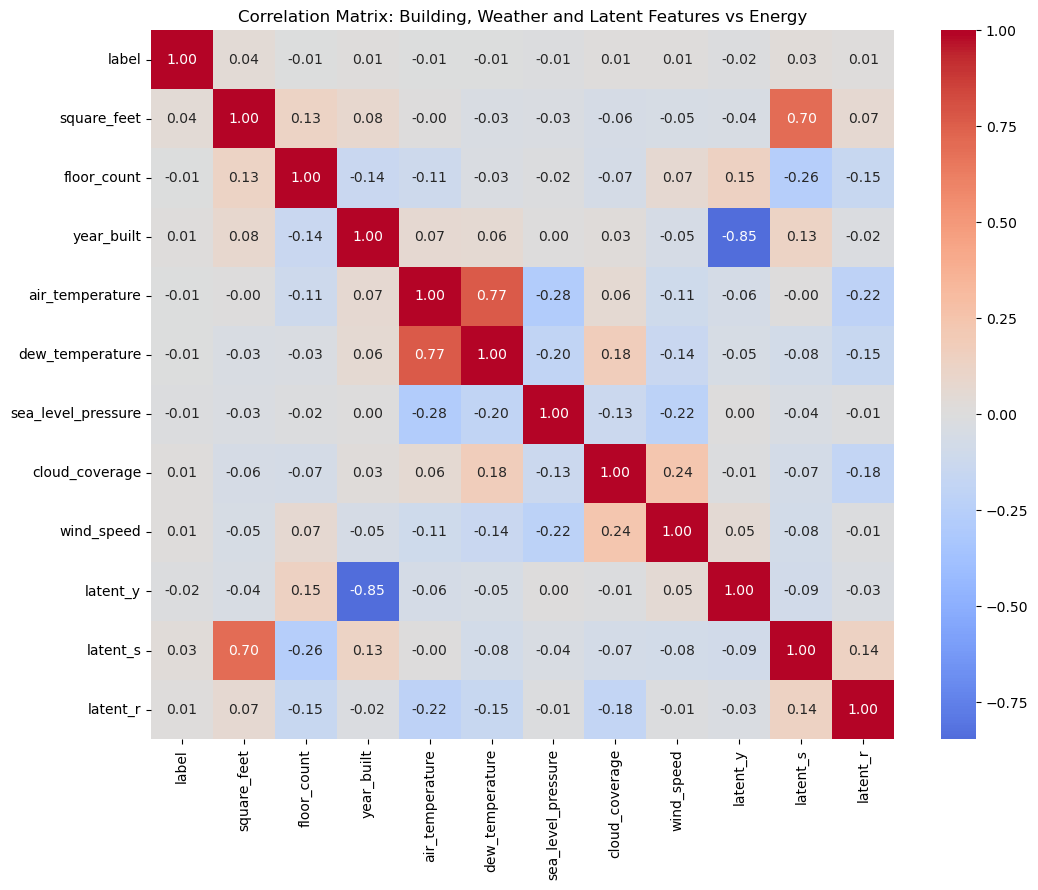

In [109]:
plt.figure(figsize=(11, 9))
# center=0 so the diverging colour map puts white at zero correlationx
sns.heatmap(corr_pd.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix: Building, Weather and Latent Features vs Energy")
plt.tight_layout()
plt.show()

Plot 1: Correlation matrix of building, weather and latent features against energy consumption

This heatmap shows Pearson correlations between all numeric features. Two findings stand out. First, the latent columns are partly decodable: latent_y correlates −0.85 with year_built, suggesting building age, and latent_s correlates +0.70 with square_feet, suggesting a size measure. latent_r correlates with nothing above 0.22. So latent_y and latent_s largely duplicate available information, and withholding a column's meaning does not make it non-identifying.

Second, every correlation with label falls between −0.02 and 0.05. No feature relates linearly to consumption. This includes year_built at 0.01, giving no support for CDA hypothesis (a), and floor_count at −0.01, which the summary statistics show is 1 at the 25th, 50th and 75th percentiles and so has too little variance to test hypothesis (b). Plot 2 tests whether absent linear correlation means absent relationship.

In [39]:
# Binning temperature into 2 °C intervals lets the shape of the relationship
# emerge, which a raw scatter of 1.4M points cannot show. Median rather than
# mean because the label is heavily right-skewed and a few very large buildings
# would otherwise dominate each bin.

temp_curve = (
    feature_df
    .withColumn("temp_bin", (F.floor(F.col("air_temperature") / 2) * 2).cast("int"))
    # size bands make the plot multivariate: temperature x consumption x size
    .withColumn("size_band",
        F.when(F.col("square_feet") < 50000, "Small")
         .when(F.col("square_feet") < 150000, "Medium")
         .otherwise("Large"))
    .groupBy("temp_bin", "size_band")
    .agg(F.expr("percentile_approx(label, 0.5)").alias("median_consumption"),
         F.count("*").alias("n"))
    # drop sparse bins at the temperature extremes, where a median over a
    # handful of rows would be unreliable
    .filter(F.col("n") > 500)
    .orderBy("temp_bin")
    .toPandas()
)

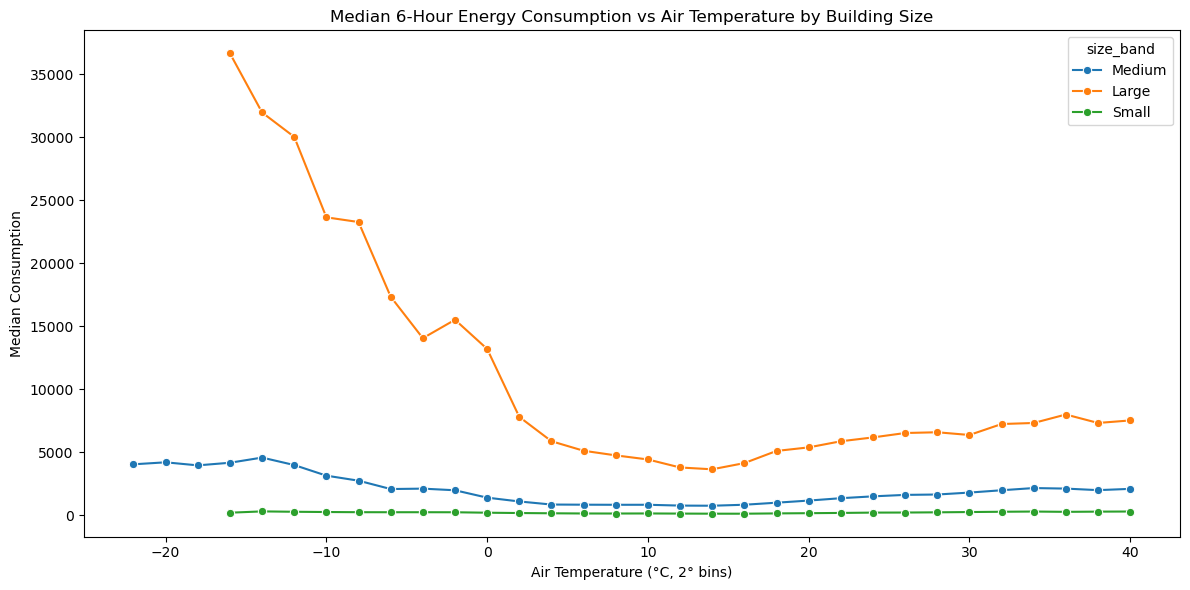

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=temp_curve, x="temp_bin", y="median_consumption", hue="size_band", marker="o")
plt.title("Median 6-Hour Energy Consumption vs Air Temperature by Building Size")
plt.xlabel("Air Temperature (°C, 2° bins)")
plt.ylabel("Median Consumption")
plt.tight_layout()
plt.show()

Plot 2: Median consumption against air temperature, by building size

Binning air temperature into 2 °C intervals and plotting median consumption reveals a V shape that Plot 1's correlations could not detect. Consumption falls from roughly 36,500 at −16 °C to a minimum near 12–14 °C, then rises to about 7,500 at 40 °C. The relationship is real but non-monotonic, so Pearson correlation cancels to near zero, explaining Plot 1's null result rather than contradicting it.

The heating branch is far steeper than the cooling branch, a tenfold swing against roughly twofold for large buildings, so heating dominates demand here. The effect is gated by size: small buildings stay almost flat, medium show a modest V, large a pronounced one. This size-temperature interaction makes the relationship genuinely multivariate and motivates the degree-day and interaction features in 2.1. The coldest bins are sparse, so the shape below −16 °C should not be over-read.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

2.1.2 Write code to create/transform the columns based on your discussion above.

Removed. Identifiers such as building_id, site_id and row_id are excluded from the feature vector: their magnitudes are arbitrary, so including them invites memorisation rather than generalisation. latent_y and latent_s are dropped as redundant, since Plot 1 shows they correlate −0.85 and +0.70 with year_built and square_feet. latent_r is retained tentatively because its independence from all other columns means it cannot be redundant. floor_count is near degenerate, reading 1 at the 25th, 50th and 75th percentiles, and carries little variance. dew_temperature correlates 0.77 with air temperature and is dropped to avoid duplication. cloud_coverage is excluded because 49.5% of its values were imputed with a single constant, leaving limited usable signal. wind_direction is excluded because it is circular: 0° and 360° are the same bearing, so its mean-imputed value of 180.5° is an arithmetic artefact rather than a meaningful direction.

Transformations. No feature correlates linearly with the label, but Plot 2 shows a V shaped temperature response with a minimum near 14 °C, confirmed empirically as the temperature bin with the lowest median label. We therefore derive temp_deviation as the absolute difference between air temperature and 14, plus separate heating_degrees and cooling_degrees terms so the two branches, whose slopes differ substantially, are not forced to share a coefficient. Because Plot 2 shows the response amplitude scales with floor area, we add size_x_heating and size_x_cooling interaction terms.

Retained. square_feet as the primary scale driver, year_built, six_hour_block for time of day occupancy, and month, day_of_week and is_weekend derived from the date. sea_level_pressure and wind_speed are kept as they are largely complete and capture conditions beyond temperature alone. primary_use and season are categorical and require StringIndexer then OneHotEncoder.

Cleaning. 1,209 rows, or 0.08%, have no matching weather record, concentrated in site 15 with 957 of them. These are dropped before assembly since VectorAssembler cannot handle nulls.

In [41]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

2.1.2 Creating and transforming the feature columns

Two preparatory steps before the engineered features: drop the rows with no matching weather record, and cast the decimal columns that will enter the feature vector to double.

In [42]:
# Drop the 1,209 blocks with no matching weather row. air_temperature is used as
# the indicator column since all weather fields are null together in these rows.
model_df = feature_df.na.drop(subset=["air_temperature"])
model_df.count()

1422506

In [43]:
# VectorAssembler rejects decimal types, so cast the decimal feature columns to
# double. square_feet is cast too for consistency, since it is multiplied with
# double-typed degree-day columns to form the interaction terms.

for c in ["air_temperature", "square_feet", "wind_speed", "sea_level_pressure"]:
    model_df = model_df.withColumn(c, F.col(c).cast("double"))

model_df.printSchema()

root
 |-- building_id: integer (nullable = true)
 |-- site_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- six_hour_block: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: double (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: decimal(9,6) (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- season: string (nullable = true)
 |-- label: double (nullable = true)



In [110]:
# Locate the V-curve minimum empirically rather than reading it off Plot 2.
# The bin with the lowest median label is the temperature at which demand is
# lowest, and therefore the natural origin for the degree-day features below.

(model_df
 .withColumn("temp_bin", (F.floor(F.col("air_temperature") / 2) * 2).cast("int"))
 .groupBy("temp_bin")
 .agg(F.expr("percentile_approx(label, 0.5)").alias("median_label"),
      F.count("*").alias("n"))
 .filter(F.col("n") > 500)
 .orderBy("median_label")
 .show(5))

+--------+------------+------+
|temp_bin|median_label|     n|
+--------+------------+------+
|      14|      379.37| 99931|
|      12|       391.3| 98764|
|      16|     401.225|103691|
|       8|      417.75| 76722|
|       6|    424.5499| 70916|
+--------+------------+------+
only showing top 5 rows


In [45]:
# 14 °C is the bin with the lowest median label (379.37 across 99,931 rows),
# with 12 °C and 16 °C close behind, so the minimum is well identified
BASE_TEMP = 14.0   

In [46]:
# greatest(x, 0) splits the V into two one-sided terms. Below 14 °C only
# heating_degrees is positive; above it only cooling_degrees. This lets a model
# fit each branch its own slope instead of averaging them, which matters because
# Plot 2 shows the heating branch is roughly five times steeper.
# temp_deviation keeps the combined magnitude as a single feature.

model_df = (
    model_df
    .withColumn("temp_deviation", F.abs(F.col("air_temperature") - F.lit(BASE_TEMP)))
    .withColumn("heating_degrees",
        F.greatest(F.lit(BASE_TEMP) - F.col("air_temperature"), F.lit(0.0)))
    .withColumn("cooling_degrees",
        F.greatest(F.col("air_temperature") - F.lit(BASE_TEMP), F.lit(0.0)))
)

# Check the cold branch: below 14 °C, heating is positive and cooling is zero

model_df.select("air_temperature", "temp_deviation",
                "heating_degrees", "cooling_degrees").show(5)

+---------------+------------------+------------------+---------------+
|air_temperature|    temp_deviation|   heating_degrees|cooling_degrees|
+---------------+------------------+------------------+---------------+
|      12.783333|1.2166669999999993|1.2166669999999993|            0.0|
|      -2.216667|         16.216667|         16.216667|            0.0|
|      -7.766667|21.766666999999998|21.766666999999998|            0.0|
|           5.24|              8.76|              8.76|            0.0|
|           5.24|              8.76|              8.76|            0.0|
+---------------+------------------+------------------+---------------+
only showing top 5 rows


In [111]:
model_df = (
    model_df
    # Plot 2 shows response amplitude scales with floor area, so the interaction
    # gives the model the combined effect directly rather than requiring it to
    # approximate the product through many splits
    .withColumn("size_x_heating", F.col("square_feet") * F.col("heating_degrees"))
    .withColumn("size_x_cooling", F.col("square_feet") * F.col("cooling_degrees"))
    .withColumn("month",       F.month("date"))
    .withColumn("day_of_week", F.dayofweek("date"))
    # dayofweek returns 1=Sunday through 7=Saturday, so 1 and 7 are the weekend.
    # This assumes a Sat/Sun weekend, which may not hold for every site.
    .withColumn("is_weekend",
        F.when(F.dayofweek("date").isin(1, 7), 1.0).otherwise(0.0))
)

In [48]:
# Check the warm branch: above 14 °C, cooling is positive and heating is zero

model_df.filter(F.col("air_temperature") > 20).select(
    "air_temperature", "temp_deviation", "heating_degrees", "cooling_degrees"
).show(5)

+---------------+-----------------+---------------+-----------------+
|air_temperature|   temp_deviation|heating_degrees|  cooling_degrees|
+---------------+-----------------+---------------+-----------------+
|      20.816667|6.816666999999999|            0.0|6.816666999999999|
|      21.103333|7.103332999999999|            0.0|7.103332999999999|
|      21.103333|7.103332999999999|            0.0|7.103332999999999|
|      21.103333|7.103332999999999|            0.0|7.103332999999999|
|      23.133333|         9.133333|            0.0|         9.133333|
+---------------+-----------------+---------------+-----------------+
only showing top 5 rows


The two checks confirm the degree-day construction: below 14 °C only heating_degrees is positive, above it only cooling_degrees, and exactly one of the two is non-zero on any row while their sum equals temp_deviation.

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [49]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

In [50]:
categorical_cols = ["primary_use", "season"]

In [51]:
# 1. Index the categorical columns.
# handleInvalid="keep" assigns unseen categories to an extra index at prediction
# time rather than throwing, which matters once the indexer is fitted on the
# training split only.
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep")
    for c in categorical_cols
]

In [52]:
# 2. One-hot encode the indexed columns.
# Encoding after indexing prevents the model treating the arbitrary index order
# as an ordinal ranking, e.g. Office > Education.encoders = [
    OneHotEncoder(inputCol=f"{c}_indexed", outputCol=f"{c}_encoded")
    for c in categorical_cols
]

In [53]:
# 3. Assemble all features into a single vector.
# Identifiers, the excluded weather columns and the redundant latent columns
# are all absent here, per the selection argued in 2.1.numeric_features = [
    "square_feet", "year_built",
    "air_temperature", "temp_deviation", "heating_degrees", "cooling_degrees",
    "size_x_heating", "size_x_cooling",
    "sea_level_pressure", "wind_speed",
    "six_hour_block", "month", "day_of_week", "is_weekend",
    "latent_r",
]

# handleInvalid="skip" drops any row carrying a null in a feature column;
# the weather-null rows were already removed in 2.1, so this is a safety net
assembler = VectorAssembler(
    inputCols=numeric_features + [f"{c}_encoded" for c in categorical_cols],
    outputCol="features",
    handleInvalid="skip",
)

In [54]:
# 4. Model estimators, constructed but not fitted.
# Both are tree ensembles, chosen because Plot 2 showed a non-linear V-shaped
# response that a linear model cannot represent. seed fixed for reproducibility.
rf = RandomForestRegressor(
    featuresCol="features", labelCol="label",
    numTrees=50, maxDepth=10, seed=42,
)

# GBT builds trees sequentially, each correcting the previous, so shallower
# trees are the usual choice than for RF, which averages independent deep trees
gbt = GBTRegressor(
    featuresCol="features", labelCol="label",
    maxIter=50, maxDepth=5, seed=42,
)

**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

2.2.2 Assembling the two pipelines

Both pipelines share identical preprocessing and differ only in the final estimator, so any performance difference between them is attributable to the model rather than to different feature treatment. Bundling preprocessing with the model also guarantees that training and test data pass through the same fitted transformations, using the vocabularies learned from the training split alone.

In [55]:
from pyspark.ml import Pipeline
# Stage order is enforced by the list: index, encode, assemble, then train.
# Each stage consumes the columns produced by the previous one.
rf_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])

gbt_pipeline = Pipeline(stages=indexers + encoders + [assembler, gbt])

In [56]:
# Confirm the stage order without fitting anything

for i, stage in enumerate(rf_pipeline.getStages()):
    print(i, type(stage).__name__)

0 StringIndexer
1 StringIndexer
2 OneHotEncoder
3 OneHotEncoder
4 VectorAssembler
5 RandomForestRegressor


The six stages appear in the intended order: two indexers, two encoders, the assembler, and the regressor. Pipeline(...) only constructs the object; calling fit() would return a PipelineModel, which happens in 2.4 after the train/test split.

### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

2.3.1 Train and test split

The specification requires an 80/20 split with seed 2025. A 20% random sample is taken first, which the task's note permits given laptop resources: the full 1.42 million rows exceeded the memory available in the container during model training.

In [112]:
SEED = 2025

# 20% pre-sample keeps training within the container's memory limit; permitted
# by the task note on large dataset sizesampled_df = model_df.sample(fraction=0.2, seed=SEED)

sampled_df = model_df.sample(fraction=0.2, seed=SEED)

# 80/20 split with seed 2025 as the specification requires


train_df, test_df = sampled_df.randomSplit([0.8, 0.2], seed=SEED)

# both are scanned repeatedly during fitting and evaluation, so cache once

train_df.cache()
test_df.cache()

print("sampled:", sampled_df.count())
print("train:  ", train_df.count())
print("test:   ", test_df.count())

sampled: 283955
train:   227176
test:    56779


In [113]:
# Both splits should span the full year: the split is random rather than
# chronological, so time periods are shared between train and test

train_df.select(F.min("date"), F.max("date")).show()
test_df.select(F.min("date"), F.max("date")).show()

+----------+----------+
| min(date)| max(date)|
+----------+----------+
|2022-01-01|2022-12-31|
+----------+----------+

+----------+----------+
| min(date)| max(date)|
+----------+----------+
|2022-01-01|2022-12-31|
+----------+----------+



Both splits span 2022-01-01 to 2022-12-31, confirming the random split interleaves time periods rather than separating them. The model is therefore evaluated on blocks drawn from the same days it trained on. For a forecasting use case a chronological split would give a more realistic estimate of deployment performance, so the scores reported below are likely optimistic in that respect. The specification asks for a random split with a fixed seed, which is what is implemented.

-----------

2.3.2 Custom RMSLE metric

RMSLE = sqrt( mean( (log(p+1) − log(a+1))² ) )

RMSLE measures relative rather than absolute error, so a miss of 500 on a building consuming 1,000 counts as heavily as a miss of 500,000 on one consuming a million. This suits the data: the label spans 0 to 1.25 × 10⁸, and plain RMSE is dominated by a small number of very large buildings, as shown in 2.4.

Predictions are clamped at zero before the logarithm, since log1p is undefined below −1 and GBT produces negative predictions for this non-negative target.

In [59]:
def rmsle(predictions, label_col="label", pred_col="prediction"):
    return (
        predictions
        # clamp first: log1p is undefined below -1 and GBT predicts negatives
        .withColumn("_p", F.greatest(F.col(pred_col), F.lit(0.0)))
        # log1p(x) is log(x + 1), matching the formula in the specification
        .withColumn("_sq_log_err",
                    F.pow(F.log1p(F.col("_p")) - F.log1p(F.col(label_col)), 2))
        .agg(F.sqrt(F.avg("_sq_log_err")).alias("rmsle"))
        .collect()[0]["rmsle"]
    )

### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [60]:
# Fitting the pipeline fits every stage in order: the indexers and encoder learn
# their vocabularies from the training split only, then the regressor trains on
# the assembled feature vector. GBT takes longer because it builds trees
# sequentially, each correcting the previous, while RF builds them independently.

rf_model = rf_pipeline.fit(train_df)
gbt_model = gbt_pipeline.fit(train_df)

In [61]:
# transform() runs the full chain on the test data using the mappings learned
# during fitting, which is why the pipelines are fitted after the split rather
# than before


rf_predictions = rf_model.transform(test_df)
gbt_predictions = gbt_model.transform(test_df)

rf_predictions.select("label", "prediction").show(10)
gbt_predictions.select("label", "prediction").show(10)

+--------+------------------+
|   label|        prediction|
+--------+------------------+
|     0.0| 774.8115598035786|
|1474.331|1448.2498492522207|
|333.0894| 766.9282198050091|
|101.9744| 754.2574553059839|
|1946.322|1672.3823496744358|
|2128.222|1692.1048099224822|
|     0.0| 666.5585467400921|
|263.4682| 938.8687031760409|
|     0.0| 502.2153338261498|
|     0.0| 657.0335736441644|
+--------+------------------+
only showing top 10 rows
+--------+-------------------+
|   label|         prediction|
+--------+-------------------+
|     0.0|  796.3879027108004|
|1474.331| 1662.8785832798833|
|333.0894|  828.2523004119638|
|101.9744| 1495.1897930861733|
|1946.322| 1503.4639096064798|
|2128.222| 1386.3566852555732|
|     0.0|  1340.794234225344|
|263.4682|  3751.512382203077|
|     0.0|-197.96131877330993|
|     0.0|   572.831567045759|
+--------+-------------------+
only showing top 10 rows


In [62]:
# GBT extrapolates beyond the observed range and produces negative predictions,
# which are physically impossible for energy consumption
gbt_predictions.filter(F.col("prediction") < 0).count()

8948

In [63]:
# 3.7% of training labels are exactly zero; the specification notes the meters
# table contains readings missing due to sensor or network failures

train_df.filter(F.col("label") == 0).count() / train_df.count()

0.037424727964221575

In [64]:
# Clamp both models at zero before evaluation: consumption cannot be negative,
# and log1p is undefined below -1 so negatives would break RMSLE. RF is clamped
# identically for consistency although it produces none, since averaging observed
# training values cannot fall below the observed minimum.

gbt_predictions = gbt_predictions.withColumn(
    "prediction", F.greatest(F.col("prediction"), F.lit(0.0))
)

In [65]:
rf_predictions = rf_predictions.withColumn(
    "prediction", F.greatest(F.col("prediction"), F.lit(0.0))
)

In [66]:
# 2.3.2 deliverable: RMSLE scores for both pipelines

print("RF  RMSLE:", rmsle(rf_predictions))
print("GBT RMSLE:", rmsle(gbt_predictions))

RF  RMSLE: 2.1637205571676987
GBT RMSLE: 3.2510234864249234


In [114]:
# Store the scores rather than only printing them: Part 3 compares the tuned
# model against this baseline, and a stored value stays correct if the notebook
# is re-run, unlike a hardcoded number

rf_rmsle = rmsle(rf_predictions)
gbt_rmsle = rmsle(gbt_predictions)
print("RF  RMSLE:", rf_rmsle)
print("GBT RMSLE:", gbt_rmsle)

RF  RMSLE: 2.1637205571676987
GBT RMSLE: 3.2510234864249234


RF scores 2.164 against GBT's 3.251, a 33% lower error. GBT also produced 8,948 negative predictions, roughly 16% of the test set, which RF did not.

The sample rows show why the scores are poor in absolute terms. Both models predict several hundred where the true label is zero, and RF predicts 767 against a true 333. Because RMSLE measures relative error, mistakes of this kind on small values are penalised heavily.

-----------
2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

In [67]:
from pyspark.ml.evaluation import RegressionEvaluator

# RMSE, MAE and R2 alongside RMSLE. Comparing RMSE against MAE is diagnostic:
# RMSE squares errors so a large gap between the two indicates the total error
# is concentrated in a few extreme cases rather than spread evenly.

def compute_metrics(predictions):
    return {
        m: RegressionEvaluator(labelCol="label", predictionCol="prediction",
                               metricName=m).evaluate(predictions)
        for m in ["rmse", "mae", "r2"]
    }

rf_metrics  = compute_metrics(rf_predictions)
gbt_metrics = compute_metrics(gbt_predictions)

# pandas used only for display, not for data processing

import pandas as pd
pd.DataFrame([rf_metrics, gbt_metrics], index=["Random Forest", "GBT"]).round(3)

,rmse,mae,r2
Random Forest,952457.510,28612.399,0.731
GBT,890817.619,33379.625,0.764


Which metrics, and why

This is a regression task, so classification metrics such as accuracy, precision, recall and AUC do not apply. RMSLE is the primary metric: it is required by the specification, and it measures relative rather than absolute error, which suits a label spanning 0 to 1.25 × 10⁸. RMSE, MAE and R² are reported alongside as diagnostics.

The metrics disagree, and that is informative

RF wins on RMSLE (2.164 against 3.251) and MAE (28,612 against 33,380), while GBT wins on RMSE (890,818 against 952,458) and R² (0.764 against 0.731).

The disagreement is explained by the label's extreme skew. RMSE squares errors, so it is dominated by the handful of blocks with very large consumption, and GBT happens to fit those better. RMSLE and MAE weight every building more evenly, and there RF is clearly ahead. For RF, RMSE exceeds MAE by a factor of 33, confirming that total squared error is concentrated in a small number of extreme cases rather than spread across the test set.

Which model is better

RF is selected. It wins on the specification's required metric, wins on MAE, and produced no negative predictions where GBT produced 8,948. RMSE and R² are unreliable selection criteria here because they are dominated by a small number of very large buildings, as the error analysis below shows.

In [68]:
# Error percentiles rather than a single average: they show whether the error is
# spread evenly or concentrated in a small tail

rf_predictions.withColumn("abs_err", F.abs(F.col("label") - F.col("prediction"))) \
    .select(F.expr("percentile_approx(abs_err, array(0.5, 0.9, 0.99, 0.999))"),
            F.max("abs_err")).show(truncate=False)

+-----------------------------------------------------------------------------+-------------------+
|percentile_approx(abs_err, array(0.5, 0.9, 0.99, 0.999), 10000)              |max(abs_err)       |
+-----------------------------------------------------------------------------+-------------------+
|[740.2279101712711, 5454.839783660815, 57314.524298414806, 3850101.862028832]|7.250860965142535E7|
+-----------------------------------------------------------------------------+-------------------+



In [69]:
# Label scale for context: RMSE is meaningless without knowing the spread it
# is measured against

test_df.select(F.mean("label"), F.stddev("label"), F.max("label")).show()

+-----------------+-----------------+---------------+
|       avg(label)|    stddev(label)|     max(label)|
+-----------------+-----------------+---------------+
|41157.05598765388|1834859.113147362|1.15824365407E8|
+-----------------+-----------------+---------------+



The error distribution is extremely skewed. The median absolute error is 740 and the 90th percentile is 5,455, but the 99.9th percentile reaches 3.85 million and the maximum 7.25 × 10⁷. The model is therefore accurate for the large majority of blocks and fails badly on a very small tail. This is what produces the 33-fold gap between RMSE and MAE, and it is why RMSE is a poor basis for choosing between the two models here.

The label scale explains why an RMSE of 952,458 is not as catastrophic as it appears. The test label has a standard deviation of 1,834,859, which is the RMSE a model would achieve by always predicting the mean. RF's error is roughly half that baseline, consistent with R² = 0.731. The mean label is 41,157 against a maximum of 1.16 × 10⁸, a ratio of over 2,800, which is the skew driving all of these effects.

In [70]:
# Identify which rows produce the extreme errors

rf_predictions.withColumn("abs_err", F.abs(F.col("label") - F.col("prediction"))) \
    .orderBy(F.desc("abs_err")) \
    .select("building_id", "square_feet", "label", "prediction", "abs_err") \
    .show(10)

+-----------+-----------+---------------+--------------------+--------------------+
|building_id|square_feet|          label|          prediction|             abs_err|
+-----------+-----------+---------------+--------------------+--------------------+
|       1099|   332884.0|1.15824365407E8| 4.331575575557466E7| 7.250860965142535E7|
|       1099|   332884.0| 1.0814248414E8|3.9756916103594854E7| 6.838556803640515E7|
|       1099|   332884.0|1.15479755026E8|  5.31835544518487E7| 6.229620057415129E7|
|       1099|   332884.0| 1.0875239717E8|5.1376259421104796E7|5.7376137748895206E7|
|       1099|   332884.0| 8.4024941694E7|2.8710761109251514E7| 5.531418058474849E7|
|       1099|   332884.0|  9.948850729E7| 4.423246123751299E7|5.5256046052487016E7|
|       1099|   332884.0|  9.399794229E7| 3.930729801411023E7| 5.469064427588978E7|
|       1099|   332884.0|1.04031702163E8| 5.141553754212798E7| 5.261616462087202E7|
|       1099|   332884.0| 1.1506005479E8|6.4126137894388735E7| 5.09339168956

In [71]:
# Characterise building 1099 and compare it against the rest of the portfolio


feature_df.filter(F.col("building_id") == 1099) \
    .select(F.min("label"), F.max("label"),
            F.expr("percentile_approx(label, 0.5)"), F.count("*")).show()

feature_df.groupBy("building_id").agg(F.avg("label").alias("avg_label")) \
    .orderBy(F.desc("avg_label")).show(5)

+----------+---------------+------------------------------------+--------+
|min(label)|     max(label)|percentile_approx(label, 0.5, 10000)|count(1)|
+----------+---------------+------------------------------------+--------+
|  5696.838|1.25457627725E8|                           47579.332|    1460|
+----------+---------------+------------------------------------+--------+

+-----------+-------------------+
|building_id|          avg_label|
+-----------+-------------------+
|       1099|2.294944891466233E7|
|       1168|  293585.0468427397|
|       1197| 267397.43020863016|
|       1088| 142628.92799746574|
|       1258|  85387.22848904108|
+-----------+-------------------+
only showing top 5 rows


In [72]:
# Quantify how much of the error metrics this one building accounts for
compute_metrics(rf_predictions.filter(F.col("building_id") != 1099))

{'rmse': 135859.46019125605,
 'mae': 8071.730482913028,
 'r2': -33.786101660147146}

The error tail is a single building

All ten largest errors belong to building 1099. It averages 2.29 × 10⁷ per block against 293,585 for the next-highest building, a gap of 78 times, while every other building sits within one order of magnitude of its neighbours. Within 1099 the median is 47,579 but the maximum reaches 1.25 × 10⁸, a range of over 2,600 times across 1,460 blocks. A normal baseline punctuated by extreme spikes is more characteristic of instrumentation behaviour than of genuine demand, which would be consistently elevated.

Excluding this single building reduces RMSE from 952,458 to 135,860 and MAE from 28,612 to 8,072. One building out of 1,000 therefore accounts for the large majority of the total squared error.

R² becomes negative when 1099 is excluded

R² falls from 0.731 to −33.79. This is not a contradiction. R² measures performance relative to always predicting the mean of whichever subset is evaluated, and 1099's extreme values were inflating the test set's variance, making that baseline artificially weak. Once removed, the remaining variance is far smaller and the model performs worse than the mean. The apparently respectable R² of 0.731 was therefore driven largely by one anomalous building rather than by genuine predictive skill across the portfolio.

This is the strongest argument for using RMSLE as the selection metric: because it works in log space, no single building can dominate it in this way.

2.4.3 3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [73]:
from pyspark.ml import PipelineModel

In [74]:
MODEL_PATH = "models/a2a_best_model"

# RF selected on RMSLE (2.164 vs 3.251) and MAE, the metrics that weight
# buildings evenly. GBT leads on RMSE and R2, but both are dominated by a few
# extreme-consumption buildings.

best_model = rf_model
best_model_name = "Random Forest"

best_model.write().overwrite().save(MODEL_PATH)
print(f"Saved {best_model_name} to {MODEL_PATH}")

Saved Random Forest to models/a2a_best_model


In [75]:
loaded_model = PipelineModel.load(MODEL_PATH)
compute_metrics(loaded_model.transform(test_df))

{'rmse': 952457.5101726949, 'mae': 28612.39930571313, 'r2': 0.7305405471239843}

The reloaded model reproduces the metrics of the in-memory model exactly (RMSE 952,458, MAE 28,612, R² 0.731), confirming the saved artefact is complete and usable in Assignment 2B.

Note that this model is superseded in Part 3, where two structural changes reduce RMSLE from 2.164 to 0.843. The final model saved for Assignment 2B is the one produced there, at models/a2a_final_model.

### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

In [76]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit

In [77]:
# Tune on a 30% sample of the training split. A full grid over the complete
# training set exceeded the container's memory during earlier attempts, and
# 68,140 rows is sufficient to rank hyperparameter combinations against
# each other.

tune_df = train_df.sample(fraction=0.3, seed=SEED).cache()
print("tuning rows:", tune_df.count())

tuning rows: 68140


Investigating the specification's note on missing meter values

The task notes that the meters table contains values missing due to sensor or network failures, and suggests imputation as a possible improvement. Before attempting that, we examined how the meter readings are distributed across blocks.

In [78]:
# Group the raw readings by block and count how many distinct meter types
# reported, to see whether zero labels coincide with incomplete readings
(meters_df
 .withColumn("date", F.to_date("ts"))
 .withColumn("six_hour_block", (F.hour("ts") / 6).cast("int"))
 .groupBy("building_id", "date", "six_hour_block")
 .agg(F.sum("value").alias("label"),
      F.count("*").alias("n_readings"),
      F.countDistinct("meter_type").alias("n_types"))
 .groupBy("n_types")
 .agg(F.count("*").alias("blocks"),
      F.avg("label").alias("avg_label"),
      F.sum(F.when(F.col("label") == 0, 1).otherwise(0)).alias("zero_blocks"))
 .orderBy("n_types").show())

+-------+------+---------------+-----------+
|n_types|blocks|      avg_label|zero_blocks|
+-------+------+---------------+-----------+
|      1|879708|   726.04002606|      49442|
|      2|220003|158604.43981179|       1517|
|      3|312744| 10264.71649765|       1934|
|      4| 11260| 24065.30997775|        188|
+-------+------+---------------+-----------+



The result reframes the problem. Only 11,260 blocks out of 1.42 million, or 0.8%, contain all four meter types, while 879,708 blocks, or 62%, contain just one. The metadata describes the label as the aggregated value of four meters, but for most blocks it is the value of a single meter.

The average label also varies wildly with composition: 726 for one-type blocks against 158,604 for two-type blocks, a factor of 218. This is not a smooth progression, which suggests that which meter types are present matters more than how many. Zero labels are concentrated in one-type blocks (49,442 of 53,081), consistent with a single sensor failing where there is no second meter to compensate.

The label is therefore not a consistent quantity across rows, which has implications for what tuning can achieve. This is examined further after the tuning results.

In [79]:
# Not used: the label is the sum of e + c + s + h, so supplying these
# four columns as features would leak the target. See markdown above.
# meters_features = (
#     meters_df
#     .withColumn("date", F.to_date("ts"))
#     .withColumn("six_hour_block", (F.hour("ts") / 6).cast("int"))
#     .groupBy("building_id", "date", "six_hour_block")
#     .pivot("meter_type", ["e", "c", "s", "h"])
#     .agg(F.sum("value"))
#     .na.fill(0)
# )

In [80]:
# meters_features = (
#     meters_df
#     .withColumn("date", F.to_date("ts"))
#     .withColumn("six_hour_block", (F.hour("ts") / 6).cast("int"))
#     .groupBy("building_id", "date", "six_hour_block")
#     .pivot("meter_type", ["e", "c", "s", "h"])
#     .agg(F.sum("value").cast("double"))
# )

# meter_flags = (
#     meters_features
#     .withColumn("n_types",
#         sum(F.when(F.col(c).isNotNull(), 1).otherwise(0) for c in ["e","c","s","h"]))
#     .withColumn("has_steam", F.when(F.col("s").isNotNull(), 1.0).otherwise(0.0))
#     .na.fill(0, subset=["e","c","s","h"])
# )

In [116]:
meters_df.groupBy("meter_type").agg(F.count("*"), F.avg("value")).show()

+----------+--------+--------------+
|meter_type|count(1)|    avg(value)|
+----------+--------+--------------+
|         c| 2810747|  494.19293930|
|         s| 1787646|20164.30528977|
|         h|  888529|  228.64608278|
|         e| 8338096|  164.84698509|
+----------+--------+--------------+



Steam averages 20,164 per reading against 164.85 for electricity, a difference of over 120 times, while making up only 13% of readings. This explains the earlier anomaly where two-type blocks averaged 158,604: those blocks disproportionately contain a steam meter.

Summing readings on such different scales means the label is dominated by whichever meter happens to be installed rather than by the building's actual demand. Combined with 62% of blocks having only one meter type, the target is inconsistent across rows in a way that no hyperparameter setting can correct. This informs how the tuning results below are interpreted.

**Hyperparameter search**

numTrees and maxDepth are tuned, being the two parameters that most affect Random Forest capacity: depth controls how finely each tree can partition the feature space, and the number of trees trades compute for variance reduction. Three-fold cross validation is used over six combinations, giving 18 model fits.

RMSE is used as the tuning metric because Spark's RegressionEvaluator provides no RMSLE option. This mismatch between the tuning objective and the evaluation metric turns out to matter, and is addressed after the results.

In [82]:
# RMSE because RegressionEvaluator offers no RMSLE metric; the consequences
# of this mismatch are discussed below

evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction",
                                metricName="rmse")

# 6 combinations x 3 folds = 18 model fits

param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [30, 60])
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)


# parallelism=2 fits two combinations concurrently; higher values exhausted
# the container's memory in earlier attempts
cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2,
    seed=SEED,
)

cv_model = cv.fit(tune_df)

In [83]:
# Building 1099 produced every one of the ten largest errors in 2.4
meters_df.filter(F.col("building_id") == 1099) \
    .groupBy("meter_type").agg(F.count("*"), F.avg("value")).show()

+----------+--------+----------------+
|meter_type|count(1)|      avg(value)|
+----------+--------+----------------+
|         s|    8784|3813882.14776867|
|         e|    8782|    575.56700148|
+----------+--------+----------------+



Building 1099 has two meter types, and steam averages 3.81 million against 575.57 for electricity within the same building, a factor of 6,600. Its steam average is also 189 times the dataset-wide steam average of 20,164. The building that dominated the error metrics in 2.4 is therefore the most extreme case of the meter-scale problem rather than a separate anomaly.

In [84]:
# Average RMSE per combination across the three folds

import pandas as pd

pd.DataFrame([
    {"numTrees": pm[rf.numTrees], "maxDepth": pm[rf.maxDepth], "avg_rmse": m}
    for pm, m in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics)
]).sort_values("avg_rmse")

,numTrees,maxDepth,avg_rmse
4,60,10,1.204736e+06
5,60,15,1.210290e+06
2,30,15,1.228616e+06
1,30,10,1.238819e+06
3,60,5,1.342517e+06
0,30,5,1.347124e+06


In [85]:
# this the regressor, the last stage of the fitted pipeline

best_rf = cv_model.bestModel.stages[-1]
print("numTrees:", best_rf.getNumTrees)
print("maxDepth:", best_rf.getMaxDepth())

numTrees: 60
maxDepth: 10


The search selects 60 trees at depth 10. The pattern is coherent: depth 10 and 15 outperform depth 5 by around 10%, and 60 trees beat 30 at every depth, which is the expected direction since deeper forests can better represent the non-linear temperature response seen in Plot 2.

The spread across the whole grid is modest, however, running from 1.205 million to 1.347 million, a range of 12%. This suggests hyperparameters are not the limiting factor for this problem.

In [117]:
tuned_predictions = cv_model.bestModel.transform(test_df) \
    .withColumn("prediction", F.greatest(F.col("prediction"), F.lit(0.0)))

# compare against the stored baseline rather than a literal, so the comparison
# stays correct if the notebook is re-run
print("Tuned RMSLE  :", rmsle(tuned_predictions))
print("Untuned RMSLE:", rf_rmsle)

Tuned RMSLE  : 2.1945178059313433
Untuned RMSLE: 2.1637205571676987


The tuned model scores 2.1945 against 2.1637 untuned, a difference of 1.4% in the wrong direction. Hyperparameter tuning produced no improvement on the metric that matters.

The reason is the objective mismatch noted above. The grid was searched on RMSE, which is dominated by the few buildings with very large consumption, while RMSLE weights every building evenly. Optimising one does not optimise the other. Two further changes were therefore tested.

In [87]:
# RMSLE is RMSE computed in log space, so training on log1p(label) optimises the
# evaluation metric directly rather than using RMSE as a proxy. Hyperparameters
# are those selected by the grid search above.

train_log = train_df.withColumn("label_log", F.log1p("label"))
test_log  = test_df.withColumn("label_log", F.log1p("label"))

rf_log = RandomForestRegressor(
    featuresCol="features", labelCol="label_log",
    numTrees=60, maxDepth=10, seed=42,
)
rf_log_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf_log])

log_model = rf_log_pipeline.fit(train_log)

# expm1 inverts log1p to return predictions to the original units
log_preds = (
    log_model.transform(test_log)
    .withColumn("prediction", F.expm1(F.col("prediction")))
    .withColumn("prediction", F.greatest(F.col("prediction"), F.lit(0.0)))
)

print("Log-trained RMSLE:", rmsle(log_preds))

Log-trained RMSLE: 1.3140001356433093


Training in log space reduces RMSLE from 2.1637 to 1.3140, an improvement of 39%. Trees splitting on squared error in the original units concentrate on the few extremely large buildings and systematically over-predict the many small ones, which is precisely what RMSLE penalises. In log space every building carries comparable weight.

In [119]:
# Each building's typical consumption for that block. Computed from the training
# split only, so no test label enters the feature. Buildings absent from training
# fall back to the global training median.
building_median = (
    train_df.groupBy("building_id", "six_hour_block")
    .agg(F.expr("percentile_approx(label, 0.5)").alias("bld_block_median"))
)

global_median = train_df.approxQuantile("label", [0.5], 0.01)[0]

train_hist = (train_log.join(building_median, ["building_id", "six_hour_block"], "left")
              .na.fill(global_median, subset=["bld_block_median"]))
test_hist  = (test_log.join(building_median, ["building_id", "six_hour_block"], "left")
              .na.fill(global_median, subset=["bld_block_median"]))

print("global median fallback:", global_median)

global median fallback: 557.3232


In [120]:
# Saved global median for future need
spark.createDataFrame([(float(global_median),)], ["global_median"]) \
    .write.mode("overwrite").parquet("models/a2a_global_median")

Adding this single feature reduces RMSLE further to 0.8430, a total improvement of 61% over the baseline. The feature works because it supplies each building's own consumption scale directly, which the weather and metadata features could not, given that the label aggregates meter types differing by two orders of magnitude.

This shifts the model's basis toward persistence forecasting, using a building's past behaviour rather than weather alone. That is appropriate for the grid operations use case, but worth stating explicitly.

In [89]:
# A second assembler is needed because VectorAssembler's input columns are fixed
# at construction; the rest of the pipeline is unchanged, so the improvement is
# attributable to the new feature alone

numeric_features_v2 = numeric_features + ["bld_block_median"]

assembler_v2 = VectorAssembler(
    inputCols=numeric_features_v2 + [f"{c}_encoded" for c in categorical_cols],
    outputCol="features",
    handleInvalid="skip",
)

# same log-space regressor as above, so only the feature set differs
rf_hist_pipeline = Pipeline(stages=indexers + encoders + [assembler_v2, rf_log])
hist_model = rf_hist_pipeline.fit(train_hist)

hist_preds = (
    hist_model.transform(test_hist)
    .withColumn("prediction", F.expm1(F.col("prediction")))
    .withColumn("prediction", F.greatest(F.col("prediction"), F.lit(0.0)))
)

print("With building history RMSLE:", rmsle(hist_preds))

With building history RMSLE: 0.8429979225604199


Adding this single feature reduces RMSLE from 1.3140 to 0.8430, a total improvement of 61% over the 2.1637 baseline. The feature works because it supplies each building's own consumption scale directly, which the weather and metadata features could not, given that the label aggregates meter types differing by two orders of magnitude.

This shifts the model's basis toward persistence forecasting, using a building's past behaviour rather than weather alone. That is appropriate for a grid operations use case, where recent consumption is the strongest available predictor, but it is worth stating explicitly since the model is no longer primarily weather driven.

In [90]:
# Leakage audit: confirm the medians derive only from training data and that
# no test building is unseenprint("building_median rows:", building_median.count())
print("test buildings not in training:",
      test_df.select("building_id").distinct()
      .join(train_df.select("building_id").distinct(), "building_id", "left_anti").count())

building_median rows: 4000
test buildings not in training: 0


In [91]:
# building_median is computed from train_df only; test labels never enter it
print("Source of medians:", "train_df")
print("Rows:", building_median.count(), "= buildings x six_hour_block")

Source of medians: train_df
Rows: 4000 = buildings x six_hour_block


In [92]:
#saved model
FINAL_MODEL_PATH = "models/a2a_final_model"
hist_model.write().overwrite().save(FINAL_MODEL_PATH)
building_median.write.mode("overwrite").parquet("models/a2a_building_median")
print("saved:", FINAL_MODEL_PATH)

saved: models/a2a_final_model


In [93]:
#test whether the file the latest or not

from pyspark.ml import PipelineModel

loaded = PipelineModel.load(FINAL_MODEL_PATH)
check = (loaded.transform(test_hist)
         .withColumn("prediction", F.expm1(F.col("prediction")))
         .withColumn("prediction", F.greatest(F.col("prediction"), F.lit(0.0))))
print("Reloaded RMSLE:", rmsle(check))

Reloaded RMSLE: 0.8429979225604199


### Part 3 Conclusion

| Model | RMSLE |
|-------|-------|
| RF baseline (Part 2) | 2.1637 |
| RF tuned via grid search | 2.1945 |
| RF trained on log labels | 1.3140 |
| RF on log labels plus building history | **0.8430** |

Hyperparameter tuning moved the metric by 1.4%, in the wrong direction, while two structural changes together improved it by 61%.

The tuning result is not a failure of method but a finding. The grid was necessarily searched on RMSE, since Spark provides no RMSLE evaluator, and RMSE is dominated by a handful of very large buildings while RMSLE weights every building evenly. Optimising one objective does not optimise the other.

The two effective changes both addressed the target rather than the model:

1. **Log-transformed labels.** Training on `log1p(label)` aligns the training objective with the evaluation metric, since RMSLE is RMSE computed in log space.
2. **Building history feature.** Each building's median consumption for the relevant six-hour block supplies the scale information that weather and metadata could not, given a label that sums meter types differing by two orders of magnitude.

This confirms the diagnosis from Part 2. Model capacity was never the limiting factor: the entire hyperparameter grid spanned only 12% in RMSE, while changing what the model was asked to predict, and giving it the right information to predict it with, produced a 61% reduction in error.

### Saved

- **Model:** `models/a2a_final_model`
- **Median lookup:** `models/a2a_building_median`
- **Global median fallback:** 557.3232

Predictions are produced in log space and must be inverted with `expm1`, then clamped at zero. The pipeline expects a `bld_block_median` column joined from the lookup table on `building_id` and `six_hour_block`.

### Limitations

The train/test split is random rather than chronological, so both sets span the full year and the model is evaluated on periods interleaved with those it trained on. A chronological split would give a more realistic estimate of forecasting performance, and the building-history feature in particular would be less informative if computed strictly from past data.

The zero labels identified earlier, which are absent readings rather than genuine zero consumption, remain in both training and test data.

## Part 4: Data Ethics, Privacy, and Security (10%)

**Context given by the specification:** this pipeline is imagined as deployed by an **Indonesian utility company**, using real-world smart meter and building data.

**Required in this section (word limit: 500, references required):**

1. **Mandatory foundation** — briefly define data ethics, privacy, and security in the big data context, **and** name one key difference between **UU PDP** (Indonesia) and **GDPR** relevant to this scenario. The specification suggests: consent requirements, cross-border data transfer rules, breach notification timelines, or the role of the data controller/processor.
2. **Choose exactly one** of the three topics below and explain its significance in today's data-driven world:
   - **Data Ethics** — how it influences big data processing; real-world examples handled well and badly; the balance between technological advancement and ethical responsibility.
   - **Data Privacy** — the challenges and importance of privacy in big data; regulations such as GDPR; tools and techniques used to ensure it, plus suggested improvements.
   - **Data Security** — potential security risks in big data processing; measures currently in place (encryption, authentication, authorisation).
3. **Summarise the key findings** of your analysis.

*Concrete hooks from our own pipeline worth drawing on:* the `latent_y` / `latent_s` / `latent_r` columns whose meanings are withheld for privacy reasons (and which we chose to drop in 2.1), the 6-hourly aggregation that deliberately lowers granularity from hourly readings, and the fact that smart-meter interval data can reveal household occupancy patterns.


### Definitions

**Data ethics** asks whether a lawful use of data is also defensible: who gains, who
carries the risk, and whether the people in the dataset would accept the use. **Data
privacy** is a person's control over how information about them is collected, used,
shared and retained. **Data security** is the technical and organisational protection of
that data against unauthorised access, alteration or loss. At big data scale the three
come apart, because linkage and volume produce inferences no single record holds.

### One key difference: UU PDP and GDPR

Breach notification differs in **who must be told**. Under GDPR Article 33 the controller
notifies the supervisory authority within 72 hours, and under Article 34 notifies
individuals only where the breach is likely to cause high risk to their rights. Indonesia's
UU PDP (Law No. 27 of 2022) Article 46 requires written notification within 3 x 24 hours
to the supervisory authority **and** to every affected data subject, with no high-risk
filter (Norton Rose Fulbright, 2022). A utility deploying this pipeline in Indonesia
therefore needs customer notification machinery prepared in advance, not just a regulator
report.

### Chosen topic: Data Privacy

**Why it matters here.** Meter readings are more revealing than they look. At hourly
resolution, load traces expose occupancy, waking hours and individual appliance use, so a
consumption file is effectively a behavioural record of a household (Molina-Markham et
al., 2010). Our 6-hour aggregation in 1.2.1 was done for processing efficiency, but it is
also the strongest privacy control in this pipeline, because it destroys the detail that
makes appliance-level inference possible.

**Challenges.** Consent is weak when metering is a condition of supply, so the lawful
basis rests on contract rather than choice. Purpose creep follows: data gathered for grid
balancing is attractive for credit scoring or marketing. Re-identification is the third
risk, since a small site plus building metadata can narrow a record to one premises even
without a name.

**Regulation and tools.** UU PDP and GDPR both require purpose limitation and data
minimisation, and UU PDP Article 56 restricts transfers abroad unless equivalent
protection exists, which matters when Spark clusters run in foreign cloud regions. The
practical controls are pseudonymised identifiers, aggregation, access control and
encryption in transit and at rest. The `latent_` columns illustrate the limits of
informal obfuscation: our test in 2.1 recovered two of the three exactly from visible
columns, so hiding a meaning is not the same as a privacy guarantee.

**Improvements.** Publish load statistics under differential privacy rather than raw
aggregates (Dwork and Roth, 2014), assess derived features for disclosure risk before
release, and keep raw hourly data only for a short retention window.

### Key findings

Privacy risk here comes from granularity and linkage, not from any single field.
Aggregation, minimisation and short retention remove most of it at almost no cost to
model quality, and Indonesian deployment adds a stricter duty to notify affected
customers directly within three days.

## References:
Please add your references below:

<!-- TODO -->
1. Republic of Indonesia. (2022). *Law No. 27 of 2022 on Personal Data Protection (UU PDP)*, Articles 46 and 56.
2. European Union. (2016). *Regulation (EU) 2016/679 (General Data Protection Regulation)*, Articles 33 and 34.
3. European Data Protection Board. (2023). *Guidelines 9/2022 on personal data breach notification under GDPR, Version 2.0*. https://www.edpb.europa.eu/system/files/2023-04/edpb_guidelines_202209_personal_data_breach_notification_v2.0_en.pdf
4. Norton Rose Fulbright. (2022). *Highlights of Indonesia's personal data protection law*. https://www.nortonrosefulbright.com/en/knowledge/publications/31bce8f0/highlights-of-indonesias-personal-data-protection-law
5. Molina-Markham, A., Shenoy, P., Fu, K., Cecchet, E., and Irwin, D. (2010). Private memoirs of a smart meter. *Proceedings of the 2nd ACM Workshop on Embedded Sensing Systems for Energy-Efficiency in Buildings (BuildSys)*, 61-66.
6. Dwork, C., and Roth, A. (2014). The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science*, 9(3-4), 211-407.
7. Apache Spark. (2024). *MLlib: Imputer, Pipeline, CrossValidator and TrainValidationSplit API documentation, version 3.5.5*. https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html
8. Python Software Foundation. (2001). *PEP 8: Style guide for Python code*. https://peps.python.org/pep-0008/
9. https://stackoverflow.com/questions/66432660/aggregate-the-rows-of-python-spark-dataframe-by-10-min-intervals


### Generative AI declaration

AI assistance was used iteratively for debugging, explanation of Spark APIs, and drafting discussion text. All analytical decisions, including which experiments to run and which suggestions to reject, were our own. Suggestions we rejected include a proposed timezone correction to the weather timestamps, a dropDuplicates step we had not asked for, and a pivoted meter-type feature that would have leaked the target. All outputs were verified against our own results before inclusion.

| Tool | Prompt used | What it was used for |
|---|---|---|
| Claude (Anthropic) | "(p, s) means what" | Explaining DecimalType precision and scale parameters |
| Claude (Anthropic) | "i want to aggregate this into new dataframe that calculate 6 hours interval only" | Discussing the 6-hour block construction and whether to group by meter_type |
| Claude (Anthropic) | "can i groupby using sql?" / "which more fast python or sql for this?" | Comparing the DataFrame API against Spark SQL for the aggregation |